In [1]:
# ======================================
# TASK 1.4 — RISK-AVERSE OFFERING STRATEGY
# ONE-PRICE AND TWO-PRICE BALANCING SCHEMES
# ======================================

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import itertools

# ======================================
# SETTINGS
# ======================================
ALPHA = 0.90
BETA_VALUES = [0.0, 10.0, 25.0, 50.0]

WIND_CSV    = 'wind_scenarios_DK2.csv'
PRICE_CSV   = 'price_scenarios_DK2.csv'
SI_CSV      = 'si_scenarios.csv'

P_NOM       = 500.0
BP_DEFICIT  = 1.25
BP_SURPLUS  = 0.85

# ======================================
# DATA LOADING
# ======================================
wind_df  = pd.read_csv(WIND_CSV,  index_col='hour')
price_df = pd.read_csv(PRICE_CSV, index_col='hour')
si_df    = pd.read_csv(SI_CSV,    index_col='scenario')

T       = 24
N_WIND  = wind_df.shape[1]
N_PRICE = price_df.shape[1]
N_SI    = si_df.shape[0]
N_SCEN  = N_WIND * N_PRICE * N_SI
PI      = 1.0 / N_SCEN

print(f"Scenarios: {N_WIND} wind x {N_PRICE} price x {N_SI} SI = {N_SCEN} total")
print(f"Scenario probability: pi = {PI:.6f}")

combos = list(itertools.product(range(N_WIND), range(N_PRICE), range(N_SI)))

# Shared wind scenarios
wind_mat = np.zeros((T, N_SCEN))

# One-price matrices: same logic as Task 1.1, using raw DA prices
price_mat_1p = np.zeros((T, N_SCEN))
bp_mat_1p    = np.zeros((T, N_SCEN))

# Two-price matrices: same logic as Task 1.2, using capped DA prices
price_mat_2p     = np.zeros((T, N_SCEN))
rate_up_mat_2p   = np.zeros((T, N_SCEN))
rate_down_mat_2p = np.zeros((T, N_SCEN))

# First build wind and raw DA price matrices
for omega, (wi, pi_i, si_k) in enumerate(combos):
    wind_mat[:, omega]     = wind_df.iloc[:, wi].values
    price_mat_1p[:, omega] = price_df.iloc[:, pi_i].values

# Two-price model uses capped DA prices, consistent with Task 1.2
price_mat_2p = np.maximum(price_mat_1p, 0.0)

# Build settlement matrices
for omega, (wi, pi_i, si_k) in enumerate(combos):
    si_path = si_df.iloc[si_k].values

    # One-price balancing price, consistent with Task 1.1
    bp_mat_1p[:, omega] = np.where(
        si_path == 1,
        price_mat_1p[:, omega] * BP_DEFICIT,
        price_mat_1p[:, omega] * BP_SURPLUS
    )

    # Two-price settlement rates, consistent with Task 1.2
    # Surplus/excess production
    rate_up_mat_2p[:, omega] = np.where(
        si_path == 1,
        price_mat_2p[:, omega],
        price_mat_2p[:, omega] * BP_SURPLUS
    )

    # Deficit/shortfall
    rate_down_mat_2p[:, omega] = np.where(
        si_path == 1,
        price_mat_2p[:, omega] * BP_DEFICIT,
        price_mat_2p[:, omega]
    )

print("Shapes:")
print("wind_mat          :", wind_mat.shape)
print("price_mat_1p      :", price_mat_1p.shape)
print("bp_mat_1p         :", bp_mat_1p.shape)
print("price_mat_2p      :", price_mat_2p.shape)
print("rate_up_mat_2p    :", rate_up_mat_2p.shape)
print("rate_down_mat_2p  :", rate_down_mat_2p.shape)

# ======================================
# HELPER: empirical lower-tail CVaR
# ======================================
def empirical_cvar(profits, alpha=ALPHA):
    q = np.quantile(profits, 1.0 - alpha)
    tail = profits[profits <= q]
    return float(np.mean(tail)) if len(tail) > 0 else float(q)

# ======================================
# ONE-PRICE CVaR MODEL
# ======================================
def solve_one_price_cvar(beta, alpha=ALPHA):
    """
    Risk-averse stochastic offering strategy under the one-price scheme.

    One-price uses raw DA prices and one balancing price matrix bp_mat_1p,
    consistent with Task 1.1.

    Objective:
        max ExpectedProfit + beta * CVaR_alpha
    """

    m = gp.Model(f"Task1_4_OnePrice_beta_{beta}")
    m.setParam("OutputFlag", 0)

    p_DA = m.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA")
    delta_up = m.addMVar((T, N_SCEN), lb=0.0, name="delta_up")
    delta_down = m.addMVar((T, N_SCEN), lb=0.0, name="delta_down")

    eta = m.addVar(lb=-GRB.INFINITY, name="eta")
    zeta = m.addMVar(N_SCEN, lb=0.0, name="zeta")

    for t in range(T):
        m.addConstr(
            delta_up[t, :] - delta_down[t, :] == wind_mat[t, :] - p_DA[t],
            name=f"imbalance_one_t{t}"
        )

    scenario_profit_expr = []

    for w in range(N_SCEN):
        profit_w = gp.quicksum(
            price_mat_1p[t, w] * p_DA[t]
            + bp_mat_1p[t, w] * delta_up[t, w]
            - bp_mat_1p[t, w] * delta_down[t, w]
            for t in range(T)
        )

        scenario_profit_expr.append(profit_w)
        m.addConstr(zeta[w] >= eta - profit_w, name=f"cvar_one_{w}")

    expected_profit_expr = gp.quicksum(PI * scenario_profit_expr[w] for w in range(N_SCEN))

    cvar_expr = eta - (1.0 / (1.0 - alpha)) * gp.quicksum(
        PI * zeta[w] for w in range(N_SCEN)
    )

    m.setObjective(expected_profit_expr + beta * cvar_expr, GRB.MAXIMIZE)
    m.update()
    print(f"Model size: {m.NumVars} variables | {m.NumConstrs} constraints")
    m.optimize()
    print(f"Solve time: {m.Runtime:.2f} seconds")

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"One-price optimization failed. Status: {m.Status}")

    p_DA_opt = p_DA.X
    delta_up_opt = delta_up.X
    delta_down_opt = delta_down.X

    da_revenue = (price_mat_1p * p_DA_opt[:, None]).sum(axis=0)
    bal_revenue = (bp_mat_1p * (delta_up_opt - delta_down_opt)).sum(axis=0)
    scenario_profits = da_revenue + bal_revenue

    return {
        "scheme": "one-price",
        "beta": beta,
        "objective": float(m.ObjVal),
        "expected_profit": float(np.sum(PI * scenario_profits)),
        "cvar_empirical": empirical_cvar(scenario_profits, alpha),
        "eta": float(eta.X),
        "p_DA_opt": p_DA_opt,
        "scenario_profits": scenario_profits,
    }

# ======================================
# TWO-PRICE CVaR MODEL
# ======================================
def solve_two_price_cvar(beta, alpha=ALPHA):
    """
    Risk-averse stochastic offering strategy under the two-price scheme.

    Two-price uses capped DA prices and separate settlement rates for
    upward and downward imbalances, consistent with Task 1.2.

    Objective:
        max ExpectedProfit + beta * CVaR_alpha
    """

    m = gp.Model(f"Task1_4_TwoPrice_beta_{beta}")
    m.setParam("OutputFlag", 0)

    p_DA = m.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA")

    # ub=P_NOM is kept for delta_up to match Task 1.2 and avoid unboundedness
    delta_up = m.addMVar((T, N_SCEN), lb=0.0, ub=P_NOM, name="delta_up")
    delta_down = m.addMVar((T, N_SCEN), lb=0.0, name="delta_down")

    eta = m.addVar(lb=-GRB.INFINITY, name="eta")
    zeta = m.addMVar(N_SCEN, lb=0.0, name="zeta")

    for t in range(T):
        m.addConstr(
            delta_up[t, :] - delta_down[t, :] == wind_mat[t, :] - p_DA[t],
            name=f"imbalance_two_t{t}"
        )

    scenario_profit_expr = []

    for w in range(N_SCEN):
        profit_w = gp.quicksum(
            price_mat_2p[t, w] * p_DA[t]
            + rate_up_mat_2p[t, w] * delta_up[t, w]
            - rate_down_mat_2p[t, w] * delta_down[t, w]
            for t in range(T)
        )

        scenario_profit_expr.append(profit_w)
        m.addConstr(zeta[w] >= eta - profit_w, name=f"cvar_two_{w}")

    expected_profit_expr = gp.quicksum(PI * scenario_profit_expr[w] for w in range(N_SCEN))

    cvar_expr = eta - (1.0 / (1.0 - alpha)) * gp.quicksum(
        PI * zeta[w] for w in range(N_SCEN)
    )

    m.setObjective(expected_profit_expr + beta * cvar_expr, GRB.MAXIMIZE)
    m.update()
    print(f"Model size: {m.NumVars} variables | {m.NumConstrs} constraints")
    m.optimize()
    print(f"Solve time: {m.Runtime:.2f} seconds")

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Two-price optimization failed. Status: {m.Status}")

    p_DA_opt = p_DA.X
    delta_up_opt = delta_up.X
    delta_down_opt = delta_down.X

    da_revenue = (price_mat_2p * p_DA_opt[:, None]).sum(axis=0)
    bal_revenue = (
        rate_up_mat_2p * delta_up_opt
        - rate_down_mat_2p * delta_down_opt
    ).sum(axis=0)
    scenario_profits = da_revenue + bal_revenue

    return {
        "scheme": "two-price",
        "beta": beta,
        "objective": float(m.ObjVal),
        "expected_profit": float(np.sum(PI * scenario_profits)),
        "cvar_empirical": empirical_cvar(scenario_profits, alpha),
        "eta": float(eta.X),
        "p_DA_opt": p_DA_opt,
        "scenario_profits": scenario_profits,
    }

# ======================================
# RUN FOR MULTIPLE BETAS
# ======================================
results_1p = []
results_2p = []

for beta in BETA_VALUES:
    print(f"Solving ONE-price for beta = {beta}")
    results_1p.append(solve_one_price_cvar(beta))

for beta in BETA_VALUES:
    print(f"Solving TWO-price for beta = {beta}")
    results_2p.append(solve_two_price_cvar(beta))

summary_1p = pd.DataFrame({
    "scheme": "one-price",
    "beta": [r["beta"] for r in results_1p],
    "expected_profit": [r["expected_profit"] for r in results_1p],
    "cvar": [r["cvar_empirical"] for r in results_1p],
    "eta": [r["eta"] for r in results_1p],
})

summary_2p = pd.DataFrame({
    "scheme": "two-price",
    "beta": [r["beta"] for r in results_2p],
    "expected_profit": [r["expected_profit"] for r in results_2p],
    "cvar": [r["cvar_empirical"] for r in results_2p],
    "eta": [r["eta"] for r in results_2p],
})

summary_all = pd.concat([summary_1p, summary_2p], ignore_index=True)

print("\n=== TASK 1.4 SUMMARY ===")
display(summary_all.round(2))

Scenarios: 20 wind x 20 price x 4 SI = 1600 total
Scenario probability: pi = 0.000625
Shapes:
wind_mat          : (24, 1600)
price_mat_1p      : (24, 1600)
bp_mat_1p         : (24, 1600)
price_mat_2p      : (24, 1600)
rate_up_mat_2p    : (24, 1600)
rate_down_mat_2p  : (24, 1600)
Solving ONE-price for beta = 0.0
Set parameter Username
Set parameter LicenseID to value 2817809
Academic license - for non-commercial use only - expires 2027-05-04
Model size: 78425 variables | 40000 constraints
Solve time: 0.26 seconds
Solving ONE-price for beta = 10.0
Model size: 78425 variables | 40000 constraints
Solve time: 0.49 seconds
Solving ONE-price for beta = 25.0
Model size: 78425 variables | 40000 constraints
Solve time: 0.60 seconds
Solving ONE-price for beta = 50.0
Model size: 78425 variables | 40000 constraints
Solve time: 0.45 seconds
Solving TWO-price for beta = 0.0
Model size: 78425 variables | 40000 constraints
Solve time: 0.83 seconds
Solving TWO-price for beta = 10.0
Model size: 78425 var

,scheme,beta,expected_profit,cvar,eta
0,one-price,0.0,333129.51,-4724.35,-41901.78
1,one-price,10.0,328579.77,-4104.76,19322.67
2,one-price,25.0,315195.13,-3298.40,19275.74
3,one-price,50.0,309296.63,-3118.06,19529.72
4,two-price,0.0,285660.87,3253.90,-43.19
5,two-price,10.0,284211.71,3832.40,14263.76
6,two-price,25.0,282532.57,3933.43,14296.19
7,two-price,50.0,281442.48,3965.49,14420.18


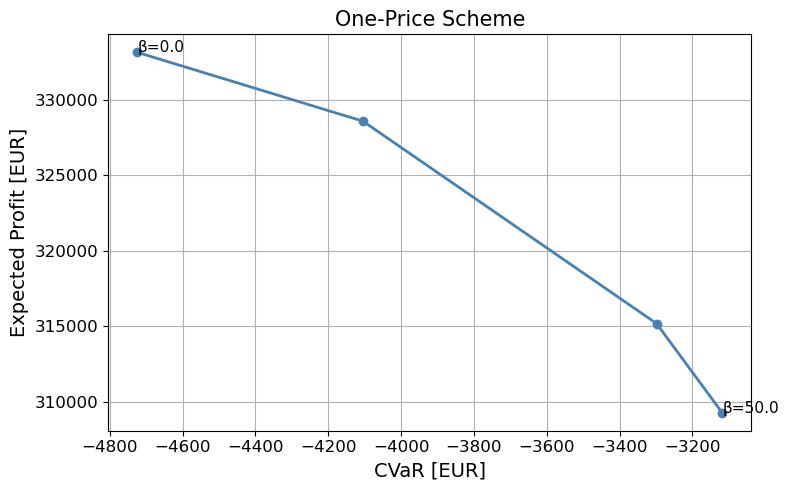

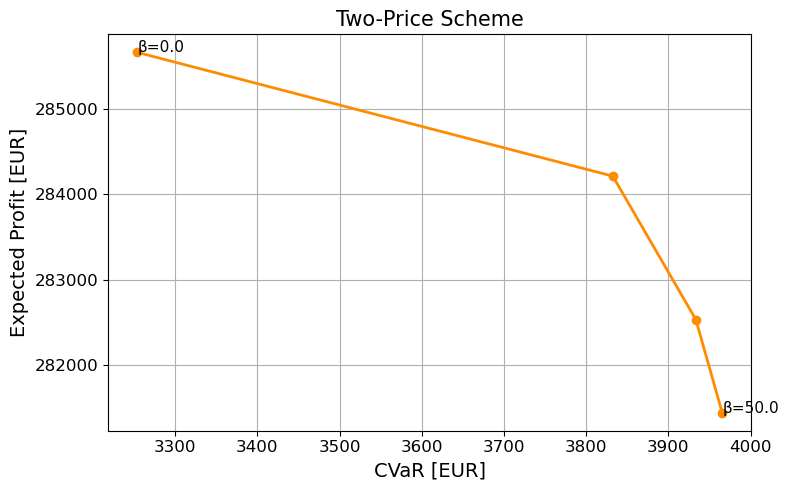

In [2]:
# ======================================
# PLOT 1A: One-price — Expected Profit vs CVaR
# ======================================
plt.figure(figsize=(8, 5))

df_1p = summary_all[summary_all["scheme"] == "one-price"].sort_values("beta")

plt.plot(df_1p["cvar"], df_1p["expected_profit"],
         marker="o", linewidth=2, color="steelblue")

for _, row in df_1p.iterrows():
    if row["beta"] in [0.0, 50.0]:
        plt.annotate(f"β={row['beta']}",
                     (row["cvar"], row["expected_profit"]),
                     fontsize=11)


plt.xlabel("CVaR [EUR]", fontsize=14)
plt.ylabel("Expected Profit [EUR]", fontsize=14)
plt.title("One-Price Scheme", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("task1_4_one_price_profit_vs_cvar.pdf", dpi=150)
plt.show()


# ======================================
# PLOT 1B: Two-price — Expected Profit vs CVaR
# ======================================
plt.figure(figsize=(8, 5))

df_2p = summary_all[summary_all["scheme"] == "two-price"].sort_values("beta")

plt.plot(df_2p["cvar"], df_2p["expected_profit"],
         marker="o", linewidth=2, color="darkorange")

for _, row in df_2p.iterrows():
    if row["beta"] in [0.0, 50.0]:
        plt.annotate(f"β={row['beta']}",
                     (row["cvar"], row["expected_profit"]),
                     fontsize=11)


plt.xlabel("CVaR [EUR]", fontsize=14)
plt.ylabel("Expected Profit [EUR]", fontsize=14)
plt.title("Two-Price Scheme", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("task1_4_two_price_profit_vs_cvar.pdf", dpi=150)
plt.show()

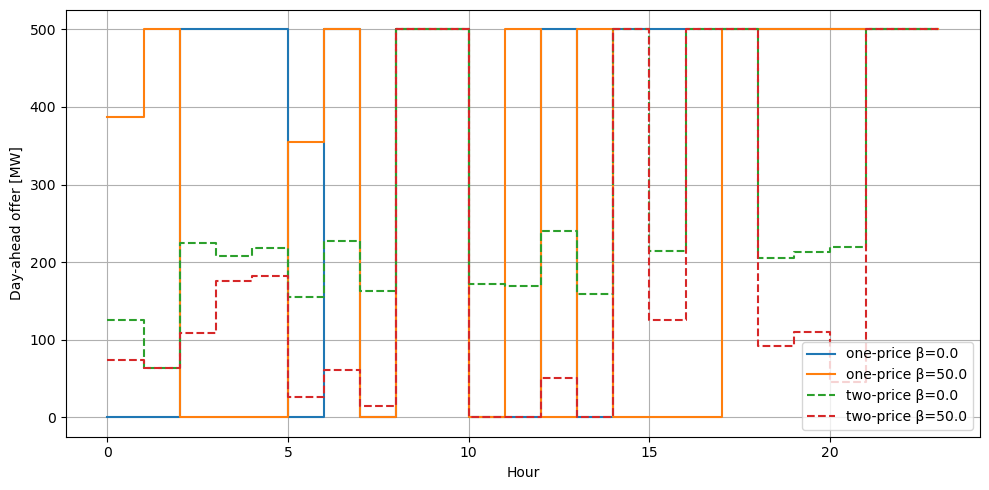

In [3]:
# ======================================
# PLOT 2: Day-ahead offers for selected betas
# ======================================
selected_betas = [0.0, 50.0]

plt.figure(figsize=(10, 5))

for r in results_1p:
    if r["beta"] in selected_betas:
        plt.step(range(T), r["p_DA_opt"], where="post", label=f"one-price β={r['beta']}")

for r in results_2p:
    if r["beta"] in selected_betas:
        plt.step(range(T), r["p_DA_opt"], where="post", linestyle="--", label=f"two-price β={r['beta']}")

plt.xlabel("Hour")
plt.ylabel("Day-ahead offer [MW]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("task1_4_day_ahead_offers.pdf", dpi=150)
plt.show()

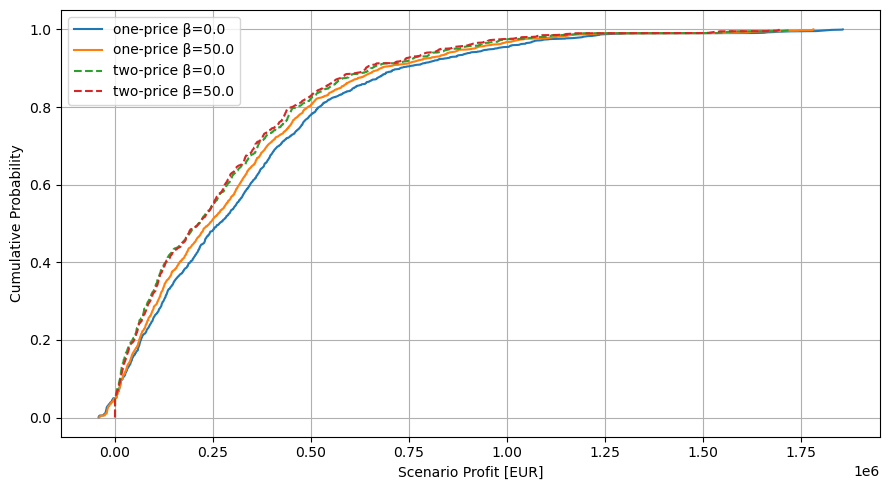

In [4]:
# ======================================
# PLOT 3: Profit distribution for selected betas
# ======================================
selected_betas = [0.0, 50.0]

plt.figure(figsize=(9, 5))

for r in results_1p:
    if r["beta"] in selected_betas:
        sorted_profit = np.sort(r["scenario_profits"])
        cdf = np.arange(1, len(sorted_profit) + 1) / len(sorted_profit)
        plt.plot(sorted_profit, cdf, label=f"one-price β={r['beta']}")

for r in results_2p:
    if r["beta"] in selected_betas:
        sorted_profit = np.sort(r["scenario_profits"])
        cdf = np.arange(1, len(sorted_profit) + 1) / len(sorted_profit)
        plt.plot(sorted_profit, cdf, linestyle="--", label=f"two-price β={r['beta']}")

plt.xlabel("Scenario Profit [EUR]")
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("task1_4_profit_distribution.pdf", dpi=150)
plt.show()

In [5]:
# ======================================
# SCENARIO SENSITIVITY: RE-SOLVE ON SMALLER IN-SAMPLE SETS
# ======================================

def solve_one_price_cvar_subset(beta, scen_idx, alpha=ALPHA):
    old_N = len(scen_idx)
    old_PI = 1.0 / old_N

    wind_sub = wind_mat[:, scen_idx]
    price_sub = price_mat_1p[:, scen_idx]
    bp_sub = bp_mat_1p[:, scen_idx]

    m = gp.Model(f"OnePrice_subset_beta_{beta}")
    m.setParam("OutputFlag", 0)

    p_DA = m.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA")
    delta_up = m.addMVar((T, old_N), lb=0.0, name="delta_up")
    delta_down = m.addMVar((T, old_N), lb=0.0, name="delta_down")
    eta = m.addVar(lb=-GRB.INFINITY, name="eta")
    zeta = m.addMVar(old_N, lb=0.0, name="zeta")

    for t in range(T):
        m.addConstr(delta_up[t, :] - delta_down[t, :] == wind_sub[t, :] - p_DA[t])

    scenario_profit_expr = []
    for w in range(old_N):
        profit_w = gp.quicksum(
            price_sub[t, w] * p_DA[t]
            + bp_sub[t, w] * delta_up[t, w]
            - bp_sub[t, w] * delta_down[t, w]
            for t in range(T)
        )
        scenario_profit_expr.append(profit_w)
        m.addConstr(zeta[w] >= eta - profit_w)

    expected_profit_expr = gp.quicksum(old_PI * scenario_profit_expr[w] for w in range(old_N))
    cvar_expr = eta - (1.0 / (1.0 - alpha)) * gp.quicksum(old_PI * zeta[w] for w in range(old_N))

    m.setObjective(expected_profit_expr + beta * cvar_expr, GRB.MAXIMIZE)
    m.update()
    print(f"Model size: {m.NumVars} variables | {m.NumConstrs} constraints")
    m.optimize()
    print(f"Solve time: {m.Runtime:.2f} seconds")

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"One-price subset optimization failed. Status: {m.Status}")

    p_DA_opt = p_DA.X
    delta_up_opt = delta_up.X
    delta_down_opt = delta_down.X

    da_revenue = (price_sub * p_DA_opt[:, None]).sum(axis=0)
    bal_revenue = (bp_sub * (delta_up_opt - delta_down_opt)).sum(axis=0)
    profits = da_revenue + bal_revenue

    return {
        "scheme": "one-price",
        "scenario_count": old_N,
        "beta": beta,
        "expected_profit": float(np.mean(profits)),
        "cvar": empirical_cvar(profits, alpha),
        "std_profit": float(np.std(profits)),
    }


def solve_two_price_cvar_subset(beta, scen_idx, alpha=ALPHA):
    old_N = len(scen_idx)
    old_PI = 1.0 / old_N

    wind_sub = wind_mat[:, scen_idx]
    price_sub = price_mat_2p[:, scen_idx]
    rate_up_sub = rate_up_mat_2p[:, scen_idx]
    rate_down_sub = rate_down_mat_2p[:, scen_idx]

    m = gp.Model(f"TwoPrice_subset_beta_{beta}")
    m.setParam("OutputFlag", 0)

    p_DA = m.addMVar(T, lb=0.0, ub=P_NOM, name="p_DA")
    delta_up = m.addMVar((T, old_N), lb=0.0, ub=P_NOM, name="delta_up")
    delta_down = m.addMVar((T, old_N), lb=0.0, name="delta_down")
    eta = m.addVar(lb=-GRB.INFINITY, name="eta")
    zeta = m.addMVar(old_N, lb=0.0, name="zeta")

    for t in range(T):
        m.addConstr(delta_up[t, :] - delta_down[t, :] == wind_sub[t, :] - p_DA[t])

    scenario_profit_expr = []
    for w in range(old_N):
        profit_w = gp.quicksum(
            price_sub[t, w] * p_DA[t]
            + rate_up_sub[t, w] * delta_up[t, w]
            - rate_down_sub[t, w] * delta_down[t, w]
            for t in range(T)
        )
        scenario_profit_expr.append(profit_w)
        m.addConstr(zeta[w] >= eta - profit_w)

    expected_profit_expr = gp.quicksum(old_PI * scenario_profit_expr[w] for w in range(old_N))
    cvar_expr = eta - (1.0 / (1.0 - alpha)) * gp.quicksum(old_PI * zeta[w] for w in range(old_N))

    m.setObjective(expected_profit_expr + beta * cvar_expr, GRB.MAXIMIZE)
    m.update()
    print(f"Model size: {m.NumVars} variables | {m.NumConstrs} constraints")
    m.optimize()
    print(f"Solve time: {m.Runtime:.2f} seconds")

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Two-price subset optimization failed. Status: {m.Status}")

    p_DA_opt = p_DA.X
    delta_up_opt = delta_up.X
    delta_down_opt = delta_down.X

    da_revenue = (price_sub * p_DA_opt[:, None]).sum(axis=0)
    bal_revenue = (rate_up_sub * delta_up_opt - rate_down_sub * delta_down_opt).sum(axis=0)
    profits = da_revenue + bal_revenue

    return {
        "scheme": "two-price",
        "scenario_count": old_N,
        "beta": beta,
        "expected_profit": float(np.mean(profits)),
        "cvar": empirical_cvar(profits, alpha),
        "std_profit": float(np.std(profits)),
    }


# Run scenario sensitivity for beta = 50
rng = np.random.default_rng(42)
TARGET_BETA = 50.0

sensitivity_rows = []

# Use already-computed full-scenario results as baseline
full_1p = next(r for r in results_1p if r["beta"] == TARGET_BETA)
full_2p = next(r for r in results_2p if r["beta"] == TARGET_BETA)

sensitivity_rows.append({
    "scheme": "one-price",
    "scenario_count": N_SCEN,
    "beta": TARGET_BETA,
    "expected_profit": full_1p["expected_profit"],
    "cvar": full_1p["cvar_empirical"],
    "std_profit": float(np.std(full_1p["scenario_profits"])),
    "scenario_set": "Full 1600"
})

sensitivity_rows.append({
    "scheme": "two-price",
    "scenario_count": N_SCEN,
    "beta": TARGET_BETA,
    "expected_profit": full_2p["expected_profit"],
    "cvar": full_2p["cvar_empirical"],
    "std_profit": float(np.std(full_2p["scenario_profits"])),
    "scenario_set": "Full 1600"
})

# Re-solve only reduced scenario sets
scenario_sets = {
    "Random 800": rng.choice(N_SCEN, size=800, replace=False),
    "Random 400": rng.choice(N_SCEN, size=400, replace=False),
}

for name, scen_idx in scenario_sets.items():
    res_1p = solve_one_price_cvar_subset(TARGET_BETA, scen_idx)
    res_1p["scenario_set"] = name
    sensitivity_rows.append(res_1p)

    res_2p = solve_two_price_cvar_subset(TARGET_BETA, scen_idx)
    res_2p["scenario_set"] = name
    sensitivity_rows.append(res_2p)

scenario_sensitivity_table = pd.DataFrame(sensitivity_rows)

print("\n=== SCENARIO SENSITIVITY: RE-SOLVED MODELS, beta = 50 ===")
display(scenario_sensitivity_table.round(2))

Model size: 39225 variables | 20000 constraints
Solve time: 0.35 seconds
Model size: 39225 variables | 20000 constraints
Solve time: 1.91 seconds
Model size: 19625 variables | 10000 constraints
Solve time: 0.08 seconds
Model size: 19625 variables | 10000 constraints
Solve time: 0.93 seconds

=== SCENARIO SENSITIVITY: RE-SOLVED MODELS, beta = 50 ===


,scheme,scenario_count,beta,expected_profit,cvar,std_profit,scenario_set
0,one-price,1600,50.0,309296.63,-3118.06,298029.87,Full 1600
1,two-price,1600,50.0,281442.48,3965.49,282778.29,Full 1600
2,one-price,800,50.0,303162.97,-1918.58,293213.94,Random 800
3,two-price,800,50.0,274827.62,4350.96,278136.73,Random 800
4,one-price,400,50.0,289718.75,-6203.54,293460.61,Random 400
5,two-price,400,50.0,272804.20,2669.32,283321.24,Random 400


In [6]:
# ======================================
# COMPACT REPORT TABLE: beta = 0 and beta = 50
# ======================================

compact_rows = []

for r in results_1p + results_2p:
    if r["beta"] in [0.0, 50.0]:
        compact_rows.append({
            "scheme": r["scheme"],
            "beta": r["beta"],
            "expected_profit": r["expected_profit"],
            "cvar": r["cvar_empirical"],
            "std_profit": float(np.std(r["scenario_profits"])),
        })

compact_results_table = pd.DataFrame(compact_rows)

print("\n=== COMPACT TASK 1.4 RESULTS TABLE ===")
display(compact_results_table.round(2))
#this is the last version


=== COMPACT TASK 1.4 RESULTS TABLE ===


,scheme,beta,expected_profit,cvar,std_profit
0,one-price,0.0,333129.51,-4724.35,313405.31
1,one-price,50.0,309296.63,-3118.06,298029.87
2,two-price,0.0,285660.87,3253.90,290695.33
3,two-price,50.0,281442.48,3965.49,282778.29
